# Used Car Market Intelligence — Classification

## Classification Track — Part A

**Objective:** classify used cars into Low, Medium, and High price classes using the `AskPrice` column.

The notebook implements the five Review 1 Part-A algorithms:
1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVC)

Evaluation uses Accuracy, weighted Precision, weighted Recall, weighted F1-score, Confusion Matrix, and multiclass ROC-AUC using One-vs-Rest (OvR).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

sns.set_palette("colorblind")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

from sklearn.preprocessing import label_binarize


Libraries imported successfully!


In [2]:
# Load the classification dataset

df = pd.read_csv("../data/used_car_dataset_classification.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (8851, 12)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,car_age
0,Honda,City,2006.5,17.5,98000.0,Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",195000,19.5
1,Toyota,Innova,2009.0,15.0,150009.5,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000,17.0
2,Volkswagen,VentoTest,2010.0,14.0,77246.0,Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999,16.0
3,Maruti Suzuki,Swift,2017.0,7.0,83500.0,Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000,9.0
4,Maruti Suzuki,Baleno,2019.0,5.0,45000.0,Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000,7.0


In [3]:
# Basic dataset audit

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (8851, 12)

Data types:
Brand            object
model            object
Year            float64
Age             float64
kmDriven        float64
Transmission     object
Owner            object
FuelType         object
PostedDate       object
AdditionInfo     object
AskPrice          int64
car_age         float64
dtype: object

Missing values:


,Missing Values
Brand,0
model,0
Year,0
Age,0
kmDriven,0
Transmission,0
Owner,0
FuelType,0
PostedDate,0
AdditionInfo,0



Duplicate rows: 1


## Target Creation

`AskPrice` is stored as text containing the rupee symbol and commas. We convert it to numeric form first.

The target is divided into three approximately equal-sized classes using quantiles:
- **Low**
- **Medium**
- **High**

This creates a multiclass classification problem while keeping the three classes reasonably balanced.


In [4]:
# Convert AskPrice to numeric

df["AskPrice"] = (
    df["AskPrice"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["AskPrice"] = pd.to_numeric(df["AskPrice"], errors="coerce")

# Remove rows where the target source is unavailable
df = df.dropna(subset=["AskPrice"]).copy()

# Create classification target if it is not already present
if "price_class" not in df.columns:
    df["price_class"] = pd.qcut(
        df["AskPrice"],
        q=3,
        labels=["Low", "Medium", "High"]
    )

print("Target created successfully.")
display(df[["AskPrice", "price_class"]].head(10))
print("\nClass distribution:")
display(df["price_class"].value_counts().sort_index())


Target created successfully.


,AskPrice,price_class
0,195000,Low
1,375000,Low
2,184999,Low
3,565000,Medium
4,685000,Medium
5,1350000,High
6,1025000,High
7,5950000,High
8,622000,Medium
9,649000,Medium



Class distribution:


price_class
Low       2961
Medium    2940
High      2950
Name: count, dtype: int64

## Feature Preparation

`AskPrice` is used only to create the target and is excluded from the model features to prevent direct target leakage.

The remaining columns are used as predictors. The preprocessing pipeline:
- imputes missing numerical values with the median,
- imputes missing categorical values with the most frequent value,
- one-hot encodes categorical variables,
- standardises numerical variables.

The preprocessing is fitted only on the training data through a scikit-learn `Pipeline`.


In [5]:
# Remove target and target-source column

X = df.drop(columns=["price_class", "AskPrice"])
y = df["price_class"]

# Drop columns that are completely empty, if any
empty_columns = X.columns[X.isna().all()].tolist()
if empty_columns:
    X = X.drop(columns=empty_columns)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)


Numerical features: ['Year', 'Age', 'kmDriven', 'car_age']

Categorical features: ['Brand', 'model', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo']


In [6]:
# Stratified 80:20 train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).sort_index())


Training set: (7080, 11)
Testing set: (1771, 11)

Training class distribution:


price_class
Low       0.334463
Medium    0.332203
High      0.333333
Name: proportion, dtype: float64

In [7]:
# Preprocessing pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## Model 1 — Logistic Regression

Logistic Regression is used as a baseline multiclass classifier.


In [8]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)
logistic_preds = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_preds)
logistic_precision = precision_score(y_test, logistic_preds, average="weighted", zero_division=0)
logistic_recall = recall_score(y_test, logistic_preds, average="weighted", zero_division=0)
logistic_f1 = f1_score(y_test, logistic_preds, average="weighted", zero_division=0)
logistic_roc_auc = roc_auc_score(
    y_test, logistic_probabilities,
    multi_class="ovr", labels=logistic_model.classes_
)

print("Logistic Regression Results")
print("-" * 40)
print(f"Accuracy:            {logistic_accuracy:.4f}")
print(f"Precision (weighted): {logistic_precision:.4f}")
print(f"Recall (weighted):    {logistic_recall:.4f}")
print(f"F1-score (weighted):  {logistic_f1:.4f}")
print(f"ROC-AUC (OvR):        {logistic_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, logistic_preds, zero_division=0))


Logistic Regression Results
----------------------------------------
Accuracy:            0.8741
Precision (weighted): 0.8750
Recall (weighted):    0.8741
F1-score (weighted):  0.8745
ROC-AUC (OvR):        0.9639

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.91      0.91       590
         Low       0.90      0.88      0.89       593
      Medium       0.81      0.83      0.82       588

    accuracy                           0.87      1771
   macro avg       0.87      0.87      0.87      1771
weighted avg       0.87      0.87      0.87      1771



## Model 2 — K-Nearest Neighbors

KNN classifies an observation using the classes of nearby observations. Scaling is important because KNN is distance-based.


In [9]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)
knn_probabilities = knn_model.predict_proba(X_test)

knn_accuracy = accuracy_score(y_test, knn_preds)
knn_precision = precision_score(y_test, knn_preds, average="weighted", zero_division=0)
knn_recall = recall_score(y_test, knn_preds, average="weighted", zero_division=0)
knn_f1 = f1_score(y_test, knn_preds, average="weighted", zero_division=0)
knn_roc_auc = roc_auc_score(
    y_test, knn_probabilities,
    multi_class="ovr", labels=knn_model.classes_
)

print("K-Nearest Neighbors Results")
print("-" * 40)
print(f"Accuracy:            {knn_accuracy:.4f}")
print(f"Precision (weighted): {knn_precision:.4f}")
print(f"Recall (weighted):    {knn_recall:.4f}")
print(f"F1-score (weighted):  {knn_f1:.4f}")
print(f"ROC-AUC (OvR):        {knn_roc_auc:.4f}")


K-Nearest Neighbors Results
----------------------------------------
Accuracy:            0.8419
Precision (weighted): 0.8418
Recall (weighted):    0.8419
F1-score (weighted):  0.8418
ROC-AUC (OvR):        0.9443


## Model 3 — Gaussian Naive Bayes

Gaussian Naive Bayes assumes conditional independence between features and models continuous features using Gaussian distributions.


In [10]:
gnb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

gnb_model.fit(X_train, y_train)
gnb_preds = gnb_model.predict(X_test)
gnb_probabilities = gnb_model.predict_proba(X_test)

gnb_accuracy = accuracy_score(y_test, gnb_preds)
gnb_precision = precision_score(y_test, gnb_preds, average="weighted", zero_division=0)
gnb_recall = recall_score(y_test, gnb_preds, average="weighted", zero_division=0)
gnb_f1 = f1_score(y_test, gnb_preds, average="weighted", zero_division=0)
gnb_roc_auc = roc_auc_score(
    y_test, gnb_probabilities,
    multi_class="ovr", labels=gnb_model.classes_
)

print("Gaussian Naive Bayes Results")
print("-" * 40)
print(f"Accuracy:            {gnb_accuracy:.4f}")
print(f"Precision (weighted): {gnb_precision:.4f}")
print(f"Recall (weighted):    {gnb_recall:.4f}")
print(f"F1-score (weighted):  {gnb_f1:.4f}")
print(f"ROC-AUC (OvR):        {gnb_roc_auc:.4f}")


Gaussian Naive Bayes Results
----------------------------------------
Accuracy:            0.6623
Precision (weighted): 0.7253
Recall (weighted):    0.6623
F1-score (weighted):  0.6405
ROC-AUC (OvR):        0.8057


## Model 4 — Decision Tree Classifier

A Decision Tree learns a sequence of feature-based rules. The tree is also useful for interpreting feature importance.


In [11]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_probabilities = dt_model.predict_proba(X_test)

dt_accuracy = accuracy_score(y_test, dt_preds)
dt_precision = precision_score(y_test, dt_preds, average="weighted", zero_division=0)
dt_recall = recall_score(y_test, dt_preds, average="weighted", zero_division=0)
dt_f1 = f1_score(y_test, dt_preds, average="weighted", zero_division=0)
dt_roc_auc = roc_auc_score(
    y_test, dt_probabilities,
    multi_class="ovr", labels=dt_model.classes_
)

print("Decision Tree Results")
print("-" * 40)
print(f"Accuracy:            {dt_accuracy:.4f}")
print(f"Precision (weighted): {dt_precision:.4f}")
print(f"Recall (weighted):    {dt_recall:.4f}")
print(f"F1-score (weighted):  {dt_f1:.4f}")
print(f"ROC-AUC (OvR):        {dt_roc_auc:.4f}")


Decision Tree Results
----------------------------------------
Accuracy:            0.7990
Precision (weighted): 0.8152
Recall (weighted):    0.7990
F1-score (weighted):  0.8027
ROC-AUC (OvR):        0.9159


## Model 5 — Support Vector Machine

A linear SVM is used because the used-car data contains one-hot encoded categorical features. A sparse feature representation is used for SVM so that training is substantially faster while preserving the required SVC algorithm.

`probability=False` is intentional: ROC-AUC is calculated directly from the SVM decision scores, so expensive probability calibration is not required.


In [12]:
# Faster Support Vector Machine using sparse one-hot features

svm_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

svm_model = Pipeline([
    ("preprocessor", svm_preprocessor),
    ("classifier", SVC(
        C=1,
        kernel="linear",
        probability=False,
        cache_size=2000,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
svm_scores = svm_model.decision_function(X_test)

svm_accuracy = accuracy_score(y_test, svm_preds)
svm_precision = precision_score(y_test, svm_preds, average="weighted", zero_division=0)
svm_recall = recall_score(y_test, svm_preds, average="weighted", zero_division=0)
svm_f1 = f1_score(y_test, svm_preds, average="weighted", zero_division=0)

# Multiclass ROC-AUC using One-vs-Rest decision scores
# probability=True is not needed, so SVM remains fast.

classes = svm_model.classes_
y_test_binary = label_binarize(y_test, classes=classes)

svm_auc_per_class = []
for i in range(len(classes)):
    svm_auc_per_class.append(
        roc_auc_score(y_test_binary[:, i], svm_scores[:, i])
    )

svm_roc_auc = np.mean(svm_auc_per_class)

print("Support Vector Machine Results")
print("-" * 40)
print(f"Accuracy:             {svm_accuracy:.4f}")
print(f"Precision (weighted): {svm_precision:.4f}")
print(f"Recall (weighted):    {svm_recall:.4f}")
print(f"F1-score (weighted):  {svm_f1:.4f}")
print(f"ROC-AUC (OvR):        {svm_roc_auc:.4f}")


Support Vector Machine Results
----------------------------------------
Accuracy:             0.8718
Precision (weighted): 0.8724
Recall (weighted):    0.8718
F1-score (weighted):  0.8721
ROC-AUC (OvR):        0.9479


## Confusion Matrices

The confusion matrix shows how many observations from each actual class were predicted as each class.


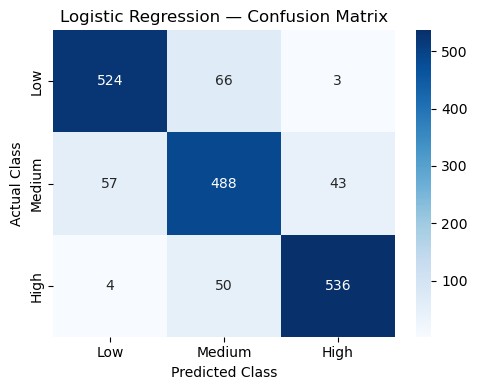

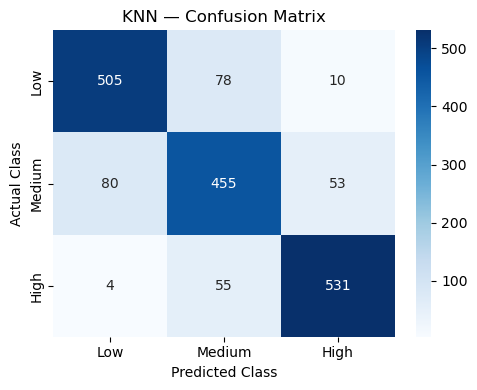

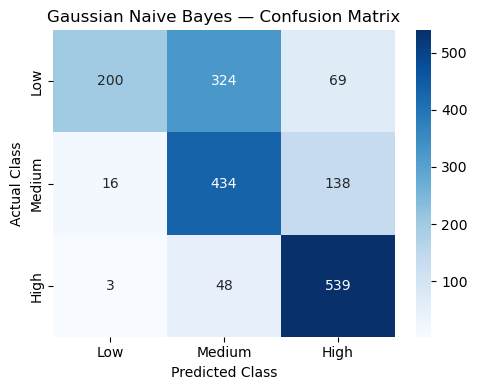

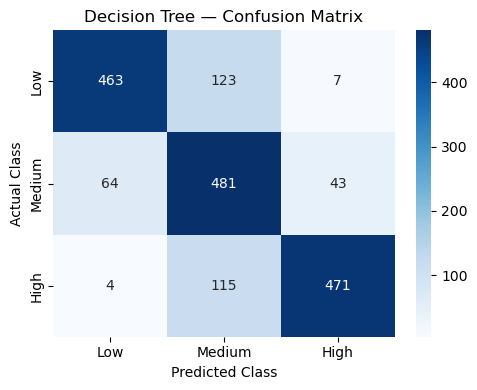

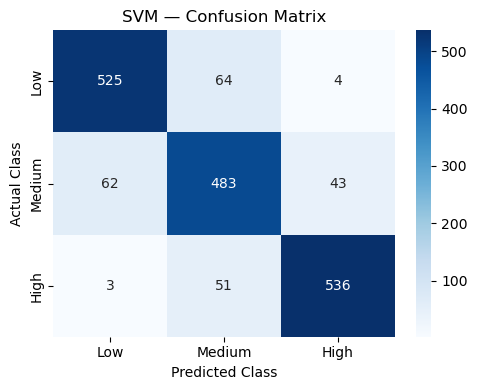

In [13]:
models_and_predictions = {
    "Logistic Regression": logistic_preds,
    "KNN": knn_preds,
    "Gaussian Naive Bayes": gnb_preds,
    "Decision Tree": dt_preds,
    "SVM": svm_preds
}

for model_name, predictions in models_and_predictions.items():
    cm = confusion_matrix(y_test, predictions, labels=["Low", "Medium", "High"])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()


## Final Comparison Table

All five Part-A algorithms are compared on the required classification metrics. ROC-AUC uses the One-vs-Rest approach for this three-class problem.


In [14]:
classification_results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        gnb_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision,
        gnb_precision,
        dt_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall,
        gnb_recall,
        dt_recall,
        svm_recall
    ],
    "F1 Score": [
        logistic_f1,
        knn_f1,
        gnb_f1,
        dt_f1,
        svm_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        knn_roc_auc,
        gnb_roc_auc,
        dt_roc_auc,
        svm_roc_auc
    ]
})

classification_results_df = (
    classification_results_df
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

display(classification_results_df.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8741,0.8750,0.8741,0.8745,0.9639
1,SVM,0.8718,0.8724,0.8718,0.8721,0.9479
2,KNN,0.8419,0.8418,0.8419,0.8418,0.9443
3,Decision Tree,0.7990,0.8152,0.7990,0.8027,0.9159
4,Gaussian Naive Bayes,0.6623,0.7253,0.6623,0.6405,0.8057


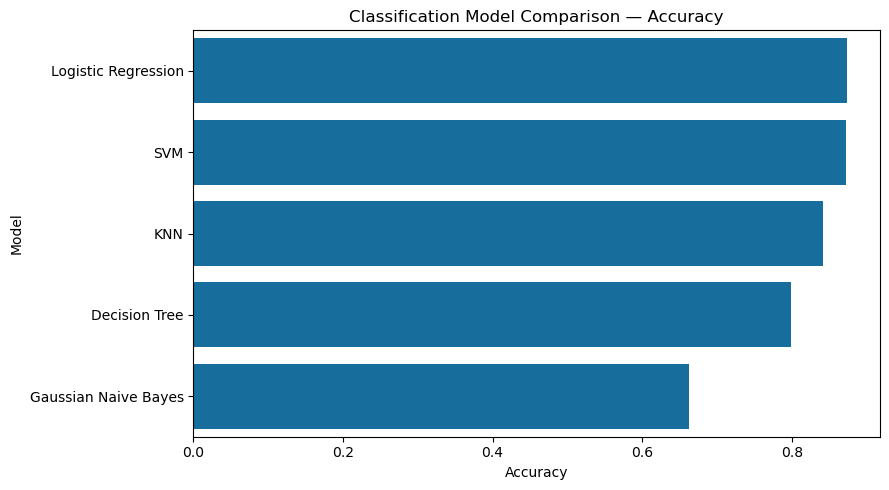

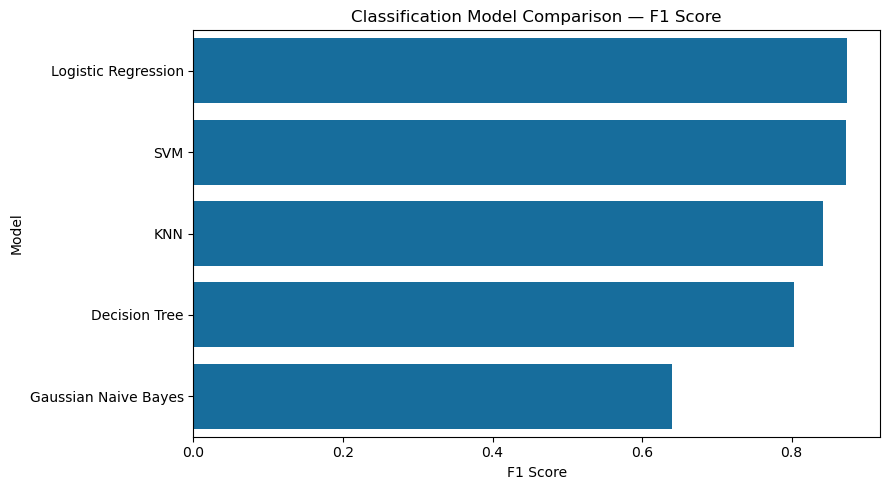

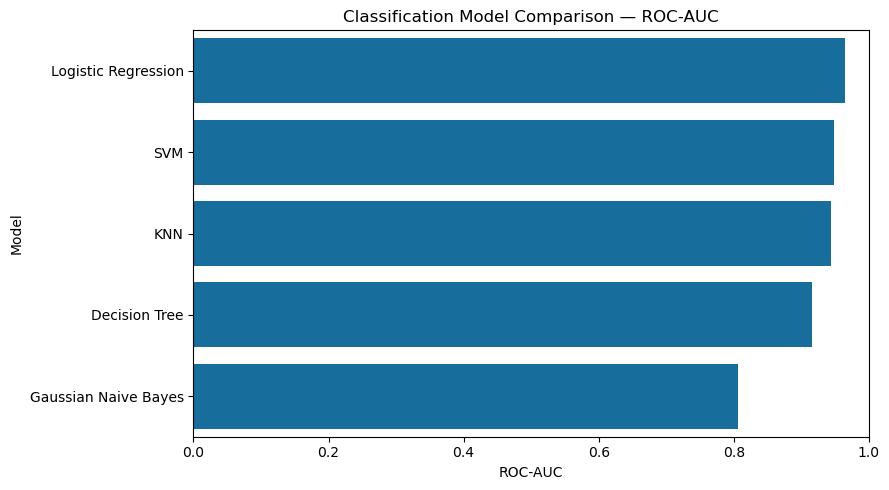

In [15]:
# Visual comparison of required metrics

for metric in ["Accuracy", "F1 Score", "ROC-AUC"]:
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=classification_results_df,
        x=metric,
        y="Model"
    )
    plt.title(f"Classification Model Comparison — {metric}")
    plt.xlabel(metric)
    plt.ylabel("Model")
    if metric == "ROC-AUC":
        plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()


## Conclusion

The five Review 1 Part-A classification algorithms were trained on the same stratified train/test split. The final table provides a consistent basis for comparing Accuracy, Precision, Recall, weighted F1-score, and ROC-AUC.

For Review 2, the five Part-B algorithms can be added to this same pipeline so that all ten classification algorithms appear in one consolidated comparison table.
